<a href="https://colab.research.google.com/github/Nobodybutyouu/FBD_detection_models/blob/main/FBD_detection_Inception_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#Step 2

import os
import numpy as np
import matplotlib.pyplot as plt
import itertools

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
#Step 3

!cp -r "/content/drive/MyDrive/ricePlant_dataSet" "/content/"

train_dir = "/content/drive/MyDrive/ricePlant_dataSet/train"
test_dir  = "/content/drive/MyDrive/ricePlant_dataSet/test"

print("Dataset copied to local runtime")

Dataset copied to local runtime


In [ ]:
IMG_SIZE = 299
BATCH_SIZE = 32
EPOCHS = 50

train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Classes: ['Healthy_images', 'Unhealthy_images']


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [ ]:
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(299,299,3)
)

base_model.trainable = False   # Freeze base layers

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 22,983,714 (87.68 MB)

 Trainable params: 1,180,930 (4.50 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 186s 7s/step - accuracy: 0.5348 - loss: 1.0703 - val_accuracy: 0.6150 - val_loss: 0.6387
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 185s 7s/step - accuracy: 0.6360 - loss: 0.7101 - val_accuracy: 0.6700 - val_loss: 0.5801
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 176s 7s/step - accuracy: 0.6712 - loss: 0.6008 - val_accuracy: 0.7150 - val_loss: 0.5360
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 174s 7s/step - accuracy: 0.7441 - loss: 0.4963 - val_accuracy: 0.7300 - val_loss: 0.4963
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 179s 7s/step - accuracy: 0.7930 - loss: 0.4904 - val_accuracy: 0.7900 - val_loss: 0.4505
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 179s 7s/step - accuracy: 0.7552 - loss: 0.4896 - val_accuracy: 0.7250 - val_loss: 0.4919
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 175s 7s/step - accuracy: 0.7706 - loss: 0.4708 - val_accuracy: 0.8000 - val_loss: 0.4240
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 176s 7s/step - accuracy: 0.7903 - loss: 0.4433 - val_accuracy: 0.8250 - v

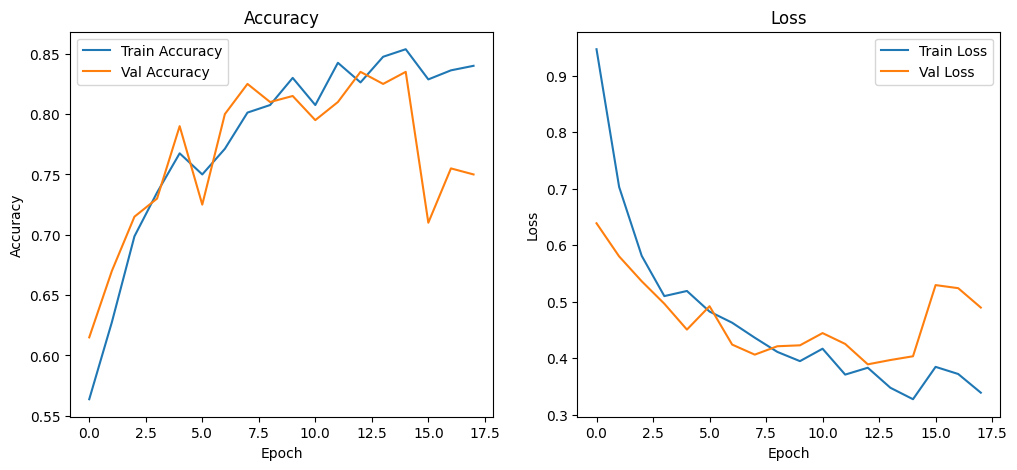

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
y_true = test_generator.classes

y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)



7/7 ━━━━━━━━━━━━━━━━━━━━ 37s 5s/step


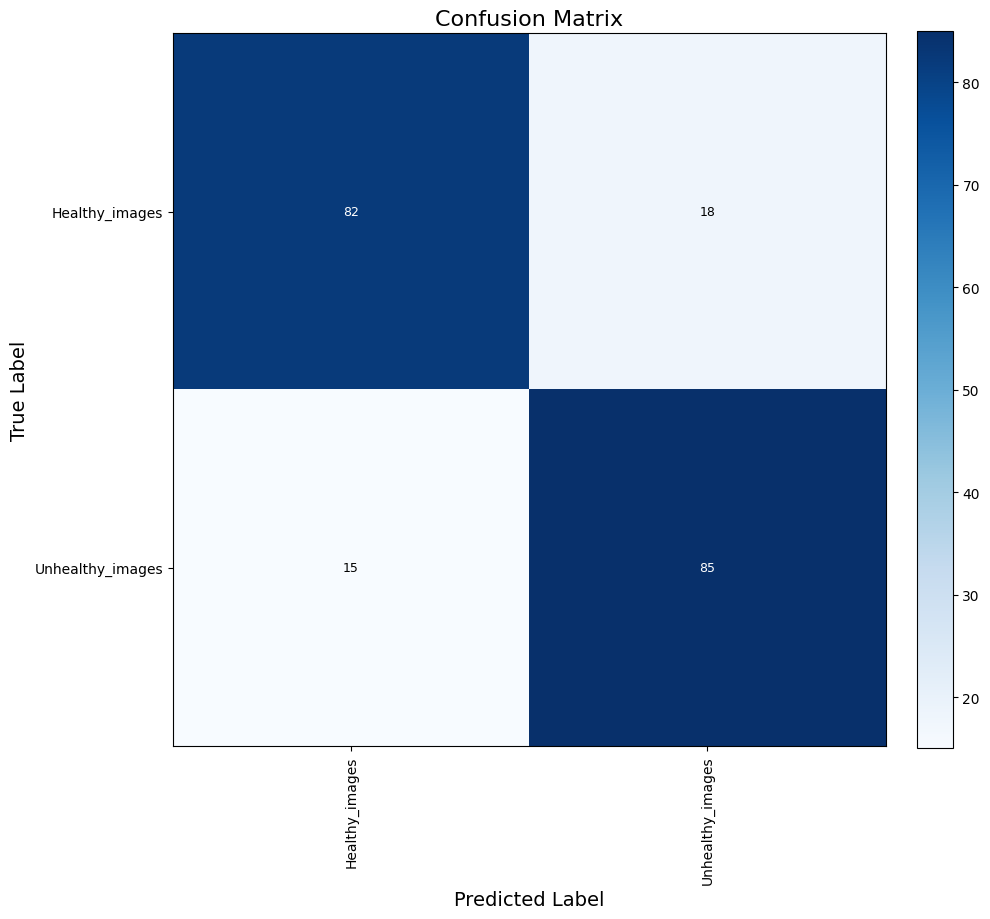

Classification Report:

                  precision    recall  f1-score   support

  Healthy_images     0.8454    0.8200    0.8325       100
Unhealthy_images     0.8252    0.8500    0.8374       100

        accuracy                         0.8350       200
       macro avg     0.8353    0.8350    0.8350       200
    weighted avg     0.8353    0.8350    0.8350       200



In [ ]:
def plot_confusion_matrix(cm, class_names):
    num_classes = len(class_names)

    fig_size = max(10, num_classes * 0.7)
    plt.figure(figsize=(fig_size, fig_size))

    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix", fontsize=16)
    plt.colorbar(fraction=0.046, pad=0.04)

    tick_marks = np.arange(num_classes)
    plt.xticks(tick_marks, class_names, rotation=90, fontsize=10)
    plt.yticks(tick_marks, class_names, fontsize=10)

    thresh = cm.max() / 2
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(
                j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                fontsize=9,
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(cm, class_names)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)
